In [1]:
# Load peristim matrix
from pathlib import Path
import numpy as np
import json
import RCP_analysis as rcp

%matplotlib inline
import matplotlib.pyplot as plt

# Paths
REPO_ROOT = Path().resolve().parents[0]
PARAMS = rcp.load_experiment_params(REPO_ROOT / "config" / "params.yaml", repo_root=REPO_ROOT)

SESSION_LOC = (Path(PARAMS.data_root) / Path(PARAMS.location)).resolve()
OUT_BASE = SESSION_LOC / "results"
OUT_BASE.mkdir(parents=True, exist_ok=True)

PERI_ROOT = OUT_BASE / "checkpoints" / "PeriStim"

CONTROL_PERI_ROOT = PERI_ROOT / "control_reaches"
AT_REST_PERI_ROOT  = PERI_ROOT / "at_rest"
STIM_PERI_ROOT  = PERI_ROOT / "stim_reaches"

INFERENCE_DATA = OUT_BASE / "checkpoints" / "inference"
INFERENCE_DATA.mkdir(parents=True, exist_ok=True)

# FILE = 'peristim__NRR_RW_013_260129_134807__BR_001_target_A.npz'
# FILE = 'peristim__NRR_RW014_260130_163551__BR_106_target_A.npz'
FILE = 'peristim__NRR_RW015_260202_113304__BR_001_target_A.npz'

# Load control
control_dir = CONTROL_PERI_ROOT / 'target_A'
control_npz_path = control_dir / FILE
control_npz = np.load(control_npz_path, allow_pickle=True)

In [2]:
# Load stim_ms
found_files = {}
files = []
stim_control_list = []
file_labels = []

stim_dir = STIM_PERI_ROOT / 'target_A'

for file in stim_dir.glob("peristim__*.npz"):
    files.append(file)

stim_npz = np.load(file, allow_pickle=True)
stim_rel_t = stim_npz['NPRW_rel_t']
meta = json.loads(stim_npz['meta_json'].item())
stim_dur = meta["recording_stim_dur"]

In [3]:
# Redo control binning
NPRW_RATES = PARAMS.NPRW_rate_est
NPRW_BIN_MS     = NPRW_RATES.get("bin_ms")
NPRW_SIGMA_MS   = NPRW_RATES.get("sigma_ms")
NPRW_MS_BEFORE = float(NPRW_RATES.get("remove_ms_before", 20.0))
NPRW_TAIL_MS   = float(NPRW_RATES.get("remove_tail_ms_after", 20.0))
NPRW_DEDUP_MS = float(NPRW_RATES.get("dedup_ms", 0.5))
MAX_CLUSTER_MS = 0.5

WIN_MS            = (-600.0, 600.0)
NORMALIZE_FIRST_MS = 150.0

# dedup peaks
control_peak_ms_dedup = control_npz['NPRW_peak_ms_dedup']
if isinstance(control_peak_ms_dedup, np.ndarray) and control_peak_ms_dedup.dtype == object:
    control_peak_ms_dedup = control_peak_ms_dedup.item()
event_ms = control_npz['event_ms']

# bin ONLY on valid stims per stream
control_counts, control_rel_t, control_edges_ms, control_left_bins = rcp.bin_counts_around_stim(
    control_peak_ms_dedup, NPRW_BIN_MS, event_ms,
    NPRW_MS_BEFORE, (stim_dur + NPRW_TAIL_MS), WIN_MS
)
control_rates_hz = rcp.smooth_counts_gauss(control_counts, control_edges_ms, control_rel_t, NPRW_SIGMA_MS, control_left_bins)
control_rates_hz_baselined = rcp.baseline_zero_each_trial(control_rates_hz, control_rel_t, normalize_first_ms=NORMALIZE_FIRST_MS)

control_rates = control_rates_hz_baselined[:, :, 29:32].mean(axis=2)

In [4]:
stim_NPRW_list = []
stim_ind_list = []
stim_response_list = []
file_labels = []
found_files = sorted(files)
    
# Session 13 file 2 weird
# Session 14 files 20

for file_idx, file in enumerate(found_files): # Remove first file because bad condition
    with np.load(file, allow_pickle=True) as npz:
        stim_rates_zeroed = npz["NPRW_rates_zeroed"]
        nprw_meta = json.loads(npz["nprw_meta_json"].item())
        stim_ch_0 = np.asarray(nprw_meta["stim_channels"], dtype=int) - 1
    n_trials_i, n_ch, n_bins = stim_rates_zeroed.shape
    if n_ch != 128 or n_trials_i < 2 or n_bins == 53:
        print(f"SKIP file_idx={file_idx} (n_ch={n_ch}): {file}")
        continue
    
    stim_NPRW_list.append(stim_rates_zeroed)
    Si = np.zeros((n_trials_i, n_ch), dtype=np.uint8)
    Si[:, stim_ch_0] = 1
    
    trial_response = stim_rates_zeroed[:, :, 29:32].mean(axis=2)

    stim_response_list.append(trial_response)
    stim_ind_list.append(Si)
    file_labels.extend([file_idx] * n_trials_i)

stim_NPRW_list_all_cond = np.concatenate(stim_NPRW_list, axis=0)
stim_ind_all_cond = np.concatenate(stim_ind_list, axis=0)
stim_response_all_cond = np.concatenate(stim_response_list, axis=0)
file_labels = np.asarray(file_labels, dtype=int)

print("Shape:", stim_NPRW_list_all_cond.shape)
print("Stim ind shape:", stim_ind_all_cond.shape)
print("Stim response shape:", stim_response_all_cond.shape)
print("#files:", len(stim_NPRW_list), "label shape:", file_labels.shape)
print("trials per file:", np.bincount(file_labels))

SKIP file_idx=0 (n_ch=128): /home/bryan/mnt/cullen/Current Project Databases - NHP/2025 Cerebellum prosthesis/Nike/20260202_NRR_RW015/results/checkpoints/PeriStim/stim_reaches/target_A/peristim__NRR_RW015_260202_113831__BR_002_target_A.npz
Shape: (713, 128, 57)
Stim ind shape: (713, 128)
Stim response shape: (713, 128)
#files: 60 label shape: (713,)
trials per file: [ 0 11 11 12 12 11 17 11 11 13 11 11 12 12 14 14 13 12 11 11 11 12 16 12
 13 15 11 10 11 12 12 14 13 14 13 12 11 12 11 11 11 12 11 10 10 12  9 11
 10 10 15 10 13 15 10 12 13 10 11 11 11]


In [5]:
from scipy.io import savemat

npz_path = INFERENCE_DATA / "session15_stim_inference_data.npz"

np.savez_compressed(
    npz_path,
    stim_rates=stim_NPRW_list_all_cond,        # (trials, ch, time)
    stim_indicator=stim_ind_all_cond,          # (trials, ch)
    stim_response=stim_response_all_cond,      # (trials, ch)
    file_labels=file_labels,                   # (trials,)
    control_rates=control_rates,         # (trials, ch)'
    time_bin_centers = control_rel_t,
    bin_dur= 20,
    stim_dur=stim_dur,
    artfact_remove_before=NPRW_MS_BEFORE,
    artfact_remove_after=NPRW_TAIL_MS,
    
)

print(f"Saved NPZ → {npz_path}")

mat_path = INFERENCE_DATA / "session15_stim_inference_data.mat"

savemat(
    mat_path,
    {
        "stim_rates": stim_NPRW_list_all_cond,
        "stim_indicator": stim_ind_all_cond,
        "stim_response": stim_response_all_cond,
        "file_labels": file_labels,
        "control_rates": control_rates,
        "time_bin_centers": control_rel_t,
        "bin_dur": 20,
        "stim_dur":stim_dur,
        "artfact_remove_before":NPRW_MS_BEFORE,
        "artfact_remove_after":NPRW_TAIL_MS,
    }
)

print(f"Saved MAT → {mat_path}")


Saved NPZ → /home/bryan/mnt/cullen/Current Project Databases - NHP/2025 Cerebellum prosthesis/Nike/20260202_NRR_RW015/results/checkpoints/inference/session15_stim_inference_data.npz
Saved MAT → /home/bryan/mnt/cullen/Current Project Databases - NHP/2025 Cerebellum prosthesis/Nike/20260202_NRR_RW015/results/checkpoints/inference/session15_stim_inference_data.mat


In [6]:
npz_path_13 = "/home/bryan/mnt/cullen/Current Project Databases - NHP/2025 Cerebellum prosthesis/Nike/20260129_NRR_RW013/results/checkpoints/inference/session13_stim_inference_data.npz"
npz_path_14 = "/home/bryan/mnt/cullen/Current Project Databases - NHP/2025 Cerebellum prosthesis/Nike/20260130_NRR_RW014/results/checkpoints/inference/session14_stim_inference_data.npz"
npz_path_15 = "/home/bryan/mnt/cullen/Current Project Databases - NHP/2025 Cerebellum prosthesis/Nike/20260202_NRR_RW015/results/checkpoints/inference/session15_stim_inference_data.npz"
npz_13 = np.load(npz_path_13)
npz_14 = np.load(npz_path_14)
npz_15 = np.load(npz_path_15)

In [7]:
# Stratify into train test across files
from sklearn.model_selection import StratifiedShuffleSplit
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.3, random_state=0)

stim_ind_13 = npz_13['stim_indicator']
control_rates_mean_13 = npz_13['control_rates'].mean(axis=0)
perturbation_13 = npz_13['stim_response'] - control_rates_mean_13[None, :]
file_labels_13 = npz_13['file_labels']
file_labels_13 = np.asarray(file_labels_13, dtype=int)
train_idx_13, test_idx_13 = next(sss.split(np.zeros(len(file_labels_13)), file_labels_13))

stim_ind_14 = npz_14['stim_indicator']
control_rates_mean_14 = npz_14['control_rates'].mean(axis=0)
perturbation_14 = npz_14['stim_response'] - control_rates_mean_14[None, :]
file_labels_14 = npz_14['file_labels']
file_labels_14 = np.asarray(file_labels_14, dtype=int)
train_idx_14, test_idx_14 = next(sss.split(np.zeros(len(file_labels_14)), file_labels_14))

stim_ind_15 = npz_15['stim_indicator']
control_rates_mean_15 = npz_15['control_rates'].mean(axis=0)
perturbation_15 = npz_15['stim_response'] - control_rates_mean_15[None, :]
file_labels_15 = npz_15['file_labels']
file_labels_15 = np.asarray(file_labels_15, dtype=int)
train_idx_15, test_idx_15 = next(sss.split(np.zeros(len(file_labels_15)), file_labels_15))


In [8]:
def sequential_W_error(stim_select, perturb, rank=10, beta=1e-2, sigma2=1.0, start=1):
    """
    """
    n_Trial, n_Ch = stim_select.shape
    I = np.eye(n_Ch) # 128x128 dim identity

    # Low-rank basis from perturb
    _, _, Vt = np.linalg.svd(perturb, full_matrices=False)
    W_lowrank = Vt[:rank].T # n_Ch, rank
    W_hat_lowrank = W_lowrank @ W_lowrank.T
    diagP = np.diag(W_hat_lowrank)
    
    # Project responses to latents
    z_latents = perturb @ W_lowrank # trial x rank

    # Use final W as ground truth
    XtX_full = stim_select.T @ stim_select
    A_full = beta * I + (1.0 / sigma2) * XtX_full

    DW_final = np.linalg.solve(A_full, (1.0 / sigma2) * stim_select.T @ z_latents)
    W_final = DW_final @ W_lowrank.T

    # Final precision logdet and covariance trace summaries
    sign_f, logdet_f = np.linalg.slogdet(A_full)
    logdet_prec_final = rank * logdet_f if sign_f > 0 else np.nan

    # trace(inv(A)) via Cholesky: tr(A^{-1}) = ||inv(L)||_F^2 where A = L L^T
    L_full = np.linalg.cholesky(A_full)
    Linv_full = np.linalg.solve(L_full, I)                  # inv(L)
    trAinv_full = np.sum(Linv_full ** 2)
    trace_cov_final = rank * sigma2 * trAinv_full

    # --- Sequential updates ---
    XtX = np.zeros((n_Ch, n_Ch))

    trial_list = []
    logdet_prec_list = []
    trace_cov_list = []
    W_error = []

    logdet_gap_list = []      # logdet_final - logdet_t
    trace_gap_list = []       # trace_t - trace_final
    trace_ratio_list = []     # trace_t / trace_final
    

    for trial in range(1, n_Trial + 1):
        x_t = stim_select[trial - 1:trial]                  # (1, n_Ch)
        XtX += x_t.T @ x_t

        if trial < start:
            continue

        trial_list.append(trial)

        X_t = stim_select[:trial]
        Z_t = z_latents[:trial]

        A_t = beta * I + (1.0 / sigma2) * XtX

        # Proj (stim -> latent) at this trial
        DW_latent = np.linalg.solve(
            A_t,
            (1.0 / sigma2) * X_t.T @ Z_t
        )
        W_hat_t = DW_latent @ W_lowrank.T

        # Error to final reference
        W_error.append(np.linalg.norm(W_hat_t - W_final, ord="fro"))

        # logdet precision (D-optimal)
        sign, logdetA = np.linalg.slogdet(A_t)
        logdet_prec_t = rank * logdetA if sign > 0 else np.nan
        logdet_prec_list.append(logdet_prec_t)
        logdet_gap_list.append(logdet_prec_final - logdet_prec_t)

        # trace covariance (A-optimal-ish)
        L = np.linalg.cholesky(A_t)
        Linv = np.linalg.solve(L, I)                        # inv(L)
        trAinv = np.sum(Linv ** 2)                          # tr(A^{-1})
        trace_cov_t = rank * sigma2 * trAinv
        trace_cov_list.append(trace_cov_t)

        # --- Covariance of W (efficient, no huge matrices) ---
        # Ainv = Linv.T @ Linv, so diag(Ainv) = sum over rows of Linv^2
        diagAinv = np.sum(Linv**2, axis=0)          # (n_Ch,) diag(A^{-1})
        diagSigmaD = sigma2 * diagAinv              # (n_Ch,) diag(Sigma_D)


        # if you want to reconstruct per-trial variance maps later:
        # diagSigmaD_list.append(diagSigmaD)

        trace_gap_list.append(trace_cov_t - trace_cov_final)
        trace_ratio_list.append(trace_cov_t / trace_cov_final if trace_cov_final != 0 else np.nan)

    return (
        trial_list,
        logdet_prec_list, trace_cov_list,
        logdet_gap_list, trace_gap_list, trace_ratio_list,
        W_error, W_final,
        W_lowrank, z_latents,
        logdet_prec_final, trace_cov_final,
        # diagP, diagSigmaD_list  # uncomment if you want full reconstruction later
    )


In [11]:
import numpy as np

def sequential_lowrank_reconst(
    stim_select,
    perturb,
    train_idx,
    test_idx,
    rank=15,
    beta=20,
    start=5,
):
    """
    """
    stim_train = stim_select[train_idx]
    stim_test  = stim_select[test_idx]
    pert_train = perturb[train_idx]
    pert_test  = perturb[test_idx]

    n_train, n_Ch = stim_train.shape
    I = np.eye(n_Ch)

    trial_list = []
    perturb_rel_err = []
    sign_acc_list = []

    for trial in range(start, n_train + 1):
        # Get basis from past data
        perturb_t = pert_train[:trial].T # channels x trials - transpose for SVD
        U_t, _, _ = np.linalg.svd(perturb_t, full_matrices=False)
        D_t = U_t[:, :rank]  # channels x rank, channel basis vectors

        # Project past response into latent space
        Z_t = D_t.T @ perturb_t # rank x nTrain

        # Use ridge fit just in case underdetermined to find optimized mapping to latents
        X_t = stim_train[:trial].T # channels x trials - transpose for SVD
        XtX = X_t @ X_t.T
        inv_term = beta * I + XtX
        W_lowrank = (Z_t @ X_t.T) @ np.linalg.inv(inv_term) # This gets the estimate of regularized low rank W
        
        # Predict perturb_test by projecting using W
        Z_test_hat = W_lowrank @ stim_test.T # rank x nTest
        pert_test_hat = D_t @ Z_test_hat # channels x nTest
        pert_test_hat = pert_test_hat.T # nTest x channels, transpose back to original shape

        # Relative RMSE
        err_fro = np.linalg.norm(pert_test_hat - pert_test, ord="fro")
        rel_err = err_fro / np.linalg.norm(pert_test, ord="fro")
        perturb_rel_err.append(rel_err)
        
        trial_list.append(trial)
        
        trial_sign_true = np.sign(np.mean(pert_test, axis=1))
        trial_sign_hat  = np.sign(np.mean(pert_test_hat, axis=1))
        trial_sign_acc = np.mean(trial_sign_true == trial_sign_hat)
        sign_acc_list.append(trial_sign_acc)

    return trial_list, perturb_rel_err, sign_acc_list, W_lowrank


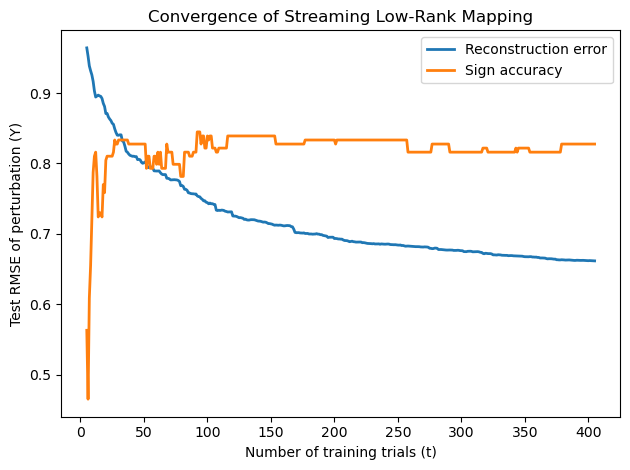

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline

# Hyperparameters
start = 5 # Try 5? TODO
beta = 20
rank = 15

# Sequential fits
trial_list_13, rel_err_13, sign_acc_13, W_lowrank_13 = sequential_lowrank_reconst(
    stim_ind_13,
    perturbation_13, train_idx_13, test_idx_13,
    rank=rank,
    beta=beta,
    start=start
)

# Y error
plt.figure()
plt.plot(trial_list_13, rel_err_13, lw=2, label='Reconstruction error')
plt.plot(trial_list_13, sign_acc_13, lw=2, label='Sign accuracy')
plt.xlabel("Number of training trials (t)")
plt.ylabel("Test RMSE of perturbation (Y)")
plt.title("Convergence of Streaming Low-Rank Mapping")
plt.legend()
plt.tight_layout()
plt.show()

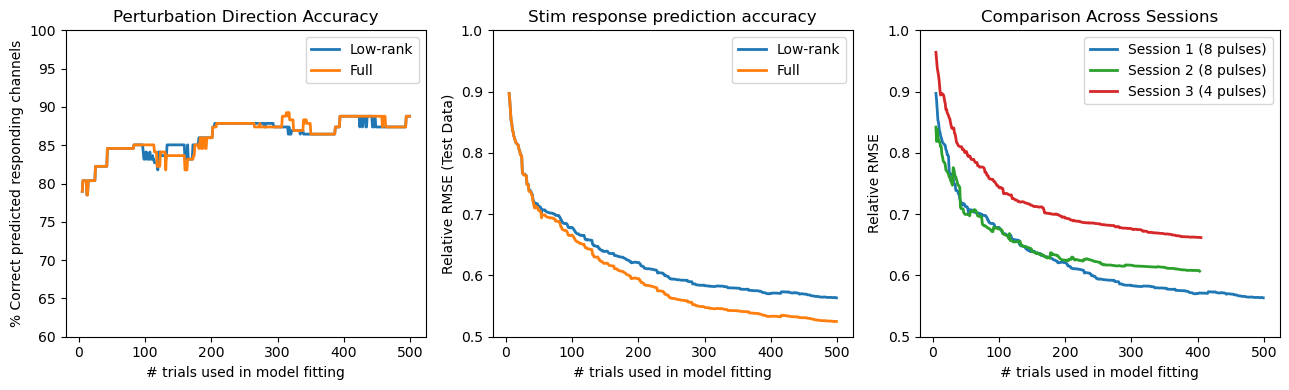

In [20]:
import matplotlib.pyplot as plt

# Hyperparameters
start = 5
beta = 20
rank = 15

# Sequential fits
trial_list_13, rel_err_13, sign_acc_13, W_lowrank_13 = sequential_lowrank_reconst(
    stim_ind_13,
    perturbation_13, train_idx_13, test_idx_13,
    rank=rank,
    beta=beta,
    start=start
)

trial_list_14, rel_err_14, sign_acc_14, W_lowrank_14 = sequential_lowrank_reconst(
    stim_ind_14,
    perturbation_14, train_idx_14, test_idx_14,
    rank=rank,
    beta=beta,
    start=start
)

trial_list_15, rel_err_15, sign_acc_15, W_lowrank_15 = sequential_lowrank_reconst(
    stim_ind_15,
    perturbation_15, train_idx_15, test_idx_15,
    rank=rank,
    beta=beta,
    start=start
)

trial_list_15_full, rel_err_15_full, sign_acc_15_full, W_lowrank_15_full = sequential_lowrank_reconst(
    stim_ind_15,
    perturbation_15, train_idx_15, test_idx_15,
    rank=128,
    beta=beta,
    start=start
)
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharex=False, sharey=False)

axes[0].plot(trial_list_15, 100*np.asarray(sign_acc_15), lw=2, label="Low-rank")
axes[0].plot(trial_list_15_full, 100*np.asarray(sign_acc_15_full), lw=2, label="Full")

axes[0].set_xlabel("# trials used in model fitting")
axes[0].set_ylabel("% Correct predicted responding channels")
axes[0].set_title("Perturbation Direction Accuracy")
axes[0].set_ylim(60, 100)
axes[0].legend()

axes[1].plot(trial_list_15, rel_err_15, lw=2, label="Low-rank")
axes[1].plot(trial_list_15_full, rel_err_15_full, lw=2, label="Full")

axes[1].set_xlabel("# trials used in model fitting")
axes[1].set_ylabel("Relative RMSE (Test Data)")
axes[1].set_title("Stim response prediction accuracy")
axes[1].set_ylim(0.5, 1)
axes[1].legend()

axes[2].plot(trial_list_15, rel_err_15, lw=2, label="Session 1 (8 pulses)")
axes[2].plot(trial_list_14, rel_err_14, lw=2, c='tab:green', label="Session 2 (8 pulses)")
axes[2].plot(trial_list_13, rel_err_13, lw=2, c='tab:red', label="Session 3 (4 pulses)")

axes[2].set_xlabel("# trials used in model fitting")
axes[2].set_ylabel("Relative RMSE")
axes[2].set_title("Comparison Across Sessions")
axes[2].set_ylim(0.5, 1)
axes[2].legend()

plt.tight_layout()
plt.show()


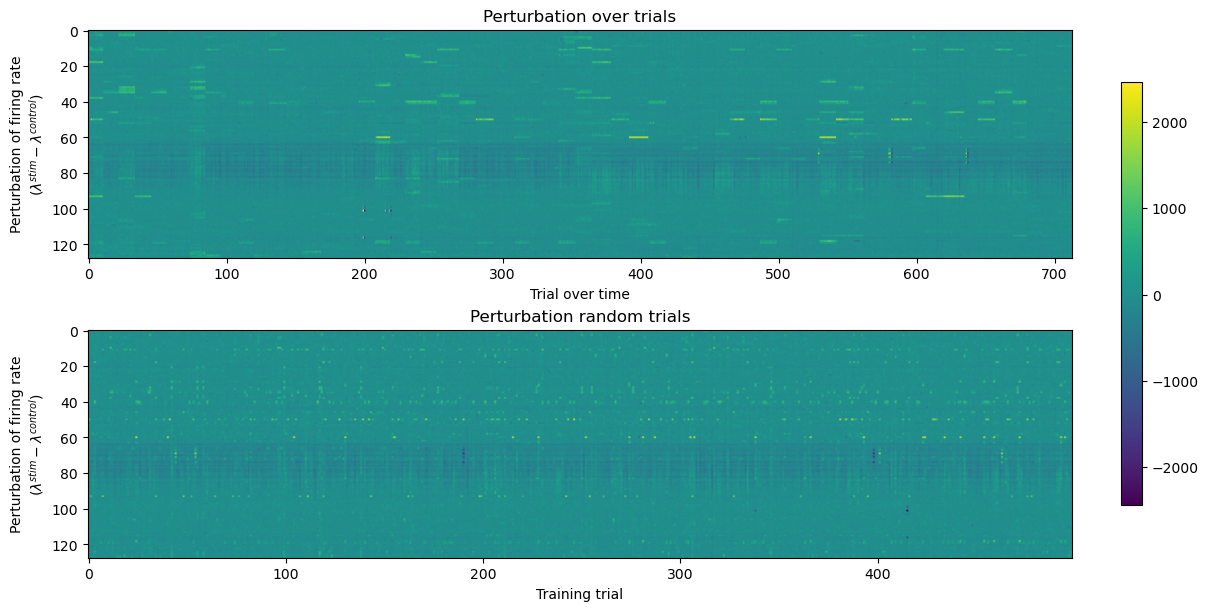

In [60]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(
    2, 1,
    figsize=(12, 6),
    constrained_layout=True
)

# Optional: shared color scale for fair comparison
vmin = min(perturbation_15.min(),
           perturbation_15[train_idx_15].min())

vmax = max(perturbation_15.max(),
           perturbation_15[train_idx_15].max())

# --- Full trials ---
im0 = axes[0].imshow(
    perturbation_15.T,
    aspect="auto",
    vmin=vmin,
    vmax=vmax
)
axes[0].set_xlabel("Trial over time")
axes[0].set_ylabel("Perturbation of firing rate\n($\\lambda^{stim}-\\lambda^{control}$)")
axes[0].set_title("Perturbation over trials")

# --- Training trials ---
im1 = axes[1].imshow(
    perturbation_15[train_idx_15].T,
    aspect="auto",
    vmin=vmin,
    vmax=vmax
)
axes[1].set_xlabel("Training trial")
axes[1].set_ylabel("Perturbation of firing rate\n($\\lambda^{stim}-\\lambda^{control}$)")
axes[1].set_title("Perturbation random trials")

# Shared colorbar
fig.colorbar(im1, ax=axes, shrink=0.8)

plt.show()


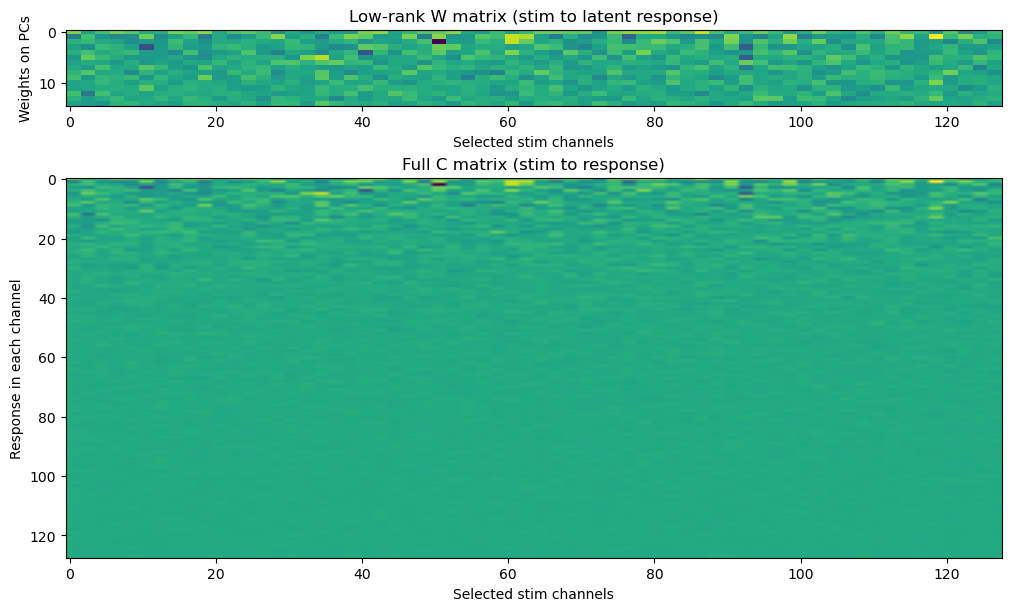

In [59]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(
    2, 1,
    figsize=(10, 6),
    gridspec_kw={"height_ratios": [1, 5]},  # top shorter, bottom taller
    constrained_layout=True
)

# Top — low rank
im0 = axes[0].imshow(W_lowrank_15, aspect="auto")
axes[0].set_title("Low-rank W matrix (stim to latent response)")
axes[0].set_xlabel("Selected stim channels")
axes[0].set_ylabel("Weights on PCs")

# Bottom — full matrix
im1 = axes[1].imshow(W_lowrank_15_full, aspect="auto")
axes[1].set_title("Full C matrix (stim to response)")
axes[1].set_xlabel("Selected stim channels")
axes[1].set_ylabel("Response in each channel")

plt.show()
